<a href="https://colab.research.google.com/github/madrimovazaxro/Car-Price-Prediction-Preprocessing-Pipeline/blob/main/lesson6_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
od.download("https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/data")

Skipping, found downloaded files in "./car-price-prediction-dataset" (use force=True to force download)


In [ ]:
df = pd.read_csv("/content/car-price-prediction-dataset/cardekho.csv")

In [ ]:
print(df.shape)
df.head()

(8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(15)


,0
seats,221
mileage(km/ltr/kg),221
engine,221
max_power,215
km_driven,0
selling_price,0
year,0
name,0
owner,0
transmission,0


In [ ]:
miss = (df.isnull().sum()/len(df)*100).round(2)
miss[miss>0].sort_values(ascending=False).head(15)

,0
mileage(km/ltr/kg),2.72
engine,2.72
seats,2.72
max_power,2.65


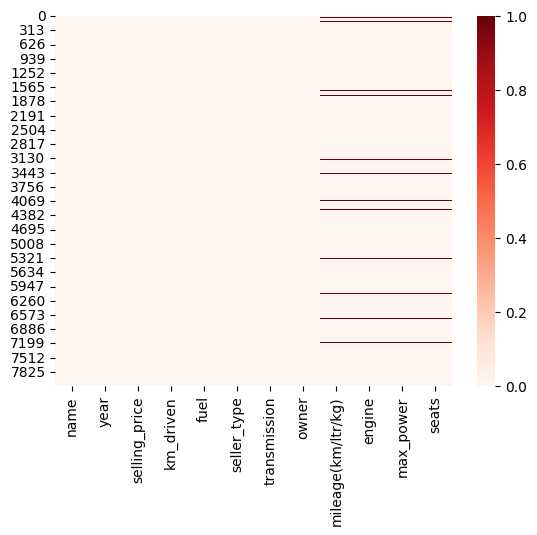

In [ ]:
sns.heatmap(df.isnull(), cbar=True, cmap="Reds")
plt.show()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


In [ ]:
cat_all = df.select_dtypes(include='object').columns
df[cat_all] = df[cat_all].fillna('None')
print(df[cat_all])

                              name    fuel seller_type transmission  \
0           Maruti Swift Dzire VDI  Diesel  Individual       Manual   
1     Skoda Rapid 1.5 TDI Ambition  Diesel  Individual       Manual   
2         Honda City 2017-2020 EXi  Petrol  Individual       Manual   
3        Hyundai i20 Sportz Diesel  Diesel  Individual       Manual   
4           Maruti Swift VXI BSIII  Petrol  Individual       Manual   
...                            ...     ...         ...          ...   
8123             Hyundai i20 Magna  Petrol  Individual       Manual   
8124         Hyundai Verna CRDi SX  Diesel  Individual       Manual   
8125        Maruti Swift Dzire ZDi  Diesel  Individual       Manual   
8126               Tata Indigo CR4  Diesel  Individual       Manual   
8127               Tata Indigo CR4  Diesel  Individual       Manual   

                     owner max_power  
0              First Owner        74  
1             Second Owner    103.52  
2              Third Owner    

In [ ]:
num = df.select_dtypes(include = "number").columns
df[num]=df[num].fillna(df[num].median())

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
print(df.duplicated().sum())

1189


In [ ]:
df.dtypes.value_counts()

,count
object,6
int64,3
float64,3


In [ ]:
Q1 = df['selling_price'].quantile(0.25)
print(Q1)
Q3 = df['selling_price'].quantile(0.75)
print(Q3)
IQR = Q3 - Q1

mask = (df["selling_price"] >= Q1 - 1.5 * IQR) & \
        (df['selling_price'] <= Q3 + 1.5 * IQR)

print(mask)
df_clean=df[mask]

270000.0
690000.0
0       True
1       True
2       True
3       True
4       True
        ... 
8123    True
8124    True
8125    True
8126    True
8127    True
Name: selling_price, Length: 7907, dtype: bool


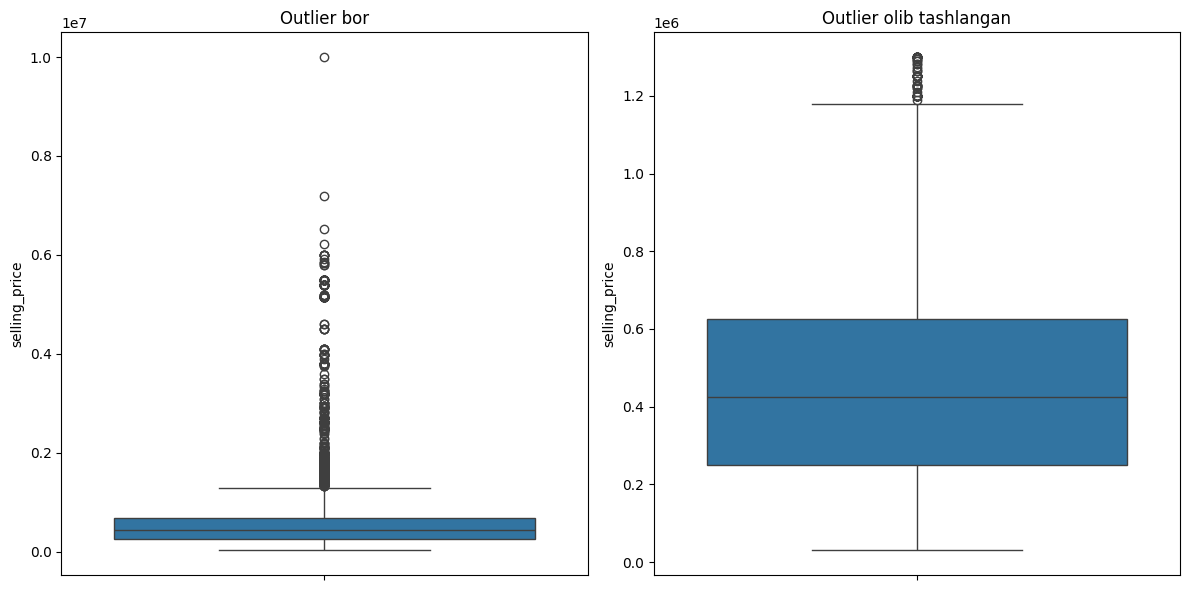

In [ ]:
fig,axes=plt.subplots(1,2, figsize=(12,6))

sns.boxplot(data=df, y='selling_price', ax=axes[0])
axes[0].set_title('Outlier bor')
sns.boxplot(data=df_clean, y='selling_price', ax=axes[1])
axes[1].set_title("Outlier olib tashlangan")
plt.tight_layout()
plt.show()

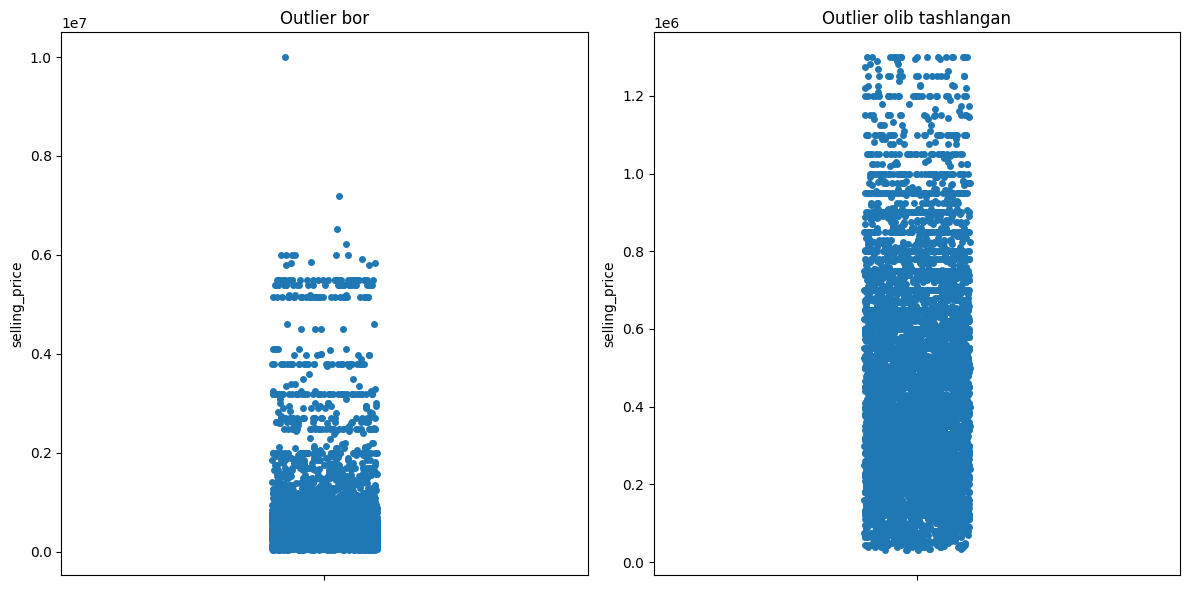

In [ ]:
fig,axes=plt.subplots(1,2, figsize=(12,6))

sns.stripplot(data=df, y='selling_price', ax=axes[0])
axes[0].set_title('Outlier bor')
sns.stripplot(data=df_clean, y='selling_price', ax=axes[1])
axes[1].set_title("Outlier olib tashlangan")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
df_clean.to_csv('df_clean.csv', index=False)
files.download('df_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7309 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7309 non-null   object 
 1   year                7309 non-null   int64  
 2   selling_price       7309 non-null   int64  
 3   km_driven           7309 non-null   int64  
 4   fuel                7309 non-null   object 
 5   seller_type         7309 non-null   object 
 6   transmission        7309 non-null   object 
 7   owner               7309 non-null   object 
 8   mileage(km/ltr/kg)  7309 non-null   float64
 9   engine              7309 non-null   float64
 10  max_power           7309 non-null   object 
 11  seats               7309 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 742.3+ KB
